In [ ]:
import numpy as np
from scipy.linalg import ldl

# Reduced-form covariance matrix (order: y1, y2)
Omega = np.array([[1.0, -0.5], [-0.5, 4.25]])

# Desired recursive structure: y2 -> y1 contemporaneously.
# To get a lower triangular matrix in the lecture's sense, we reverse the order.
Omega_rev = np.array([[4.25, -0.5], [-0.5, 1.0]])

# LDL decomposition: Omega_rev = L @ D @ L.T, L lower triangular with ones on diagonal
L_rev, D_rev, _ = ldl(Omega_rev, lower=True)   # L_rev is lower triangular with ones

# L_rev is the matrix such that epsilon_rev = L_rev @ u_rev, with u_rev ~ (0, D_rev)
# Then the structural form for the reversed order is L_rev^{-1} Y_rev = ...
# L_rev^{-1} is also lower triangular and gives contemporaneous relations.
L_rev_inv = np.linalg.inv(L_rev)

# Transform back to original order (y1, y2). Permutation matrix P swaps (y1,y2) to (y2,y1)
P = np.array([[0, 1], [1, 0]])
# In original order, epsilon = P.T @ L_rev @ u_rev.  The structural shocks u are u_rev.
# The matrix that gives u from epsilon is B = L_rev^{-1} @ P
B = L_rev_inv @ P   # This is the contemporaneous matrix in original order
# Normalize so that diagonal entries are 1 (here they already are)
print("Contemporaneous matrix B (original order):\n", B)
print("Diagonal covariance D:\n", D_rev)

Contemporaneous matrix B (original order):
 [[0.         1.        ]
 [1.         0.11764706]]
Diagonal covariance D:
 [[4.25       0.        ]
 [0.         0.94117647]]


Task 2

In [ ]:
# Установка Python-пакетов (выполните один раз)
!pip install pandas numpy matplotlib statsmodels scipy rpy2

In [ ]:
# Настройка rpy2 с возможностью использования упрощённых тестов, если R-пакеты не устанавливаются
import subprocess
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Активируем rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
pandas2ri.activate()

# Функция для получения персональной библиотеки R
def get_r_user_lib():
    r_code = """
    lib <- Sys.getenv("R_LIBS_USER")
    if (!dir.exists(lib)) dir.create(lib, recursive = TRUE)
    cat(lib)
    """
    try:
        res = ro.r(r_code)
        return res[0] if res is not None else None
    except:
        return None

user_lib = get_r_user_lib()
if user_lib:
    ro.r(f'.libPaths(c("{user_lib}", .libPaths()))')

# Пытаемся загрузить portes
try:
    portes = importr('portes')
    PORTES_AVAILABLE = True
    print("R-пакет portes успешно загружен. Будем использовать точные тесты.")
except:
    PORTES_AVAILABLE = False
    warnings.warn("R-пакет portes не удалось загрузить. Будем использовать упрощённые тесты (Python).")

# Определяем функции диагностики
def hosking_test(residuals, lags):
    """Тест Хоскинга (R или упрощённый Python)."""
    if PORTES_AVAILABLE:
        with localconverter(ro.default_converter + pandas2ri.converter):
            r_resid = ro.conversion.py2rpy(residuals)
        res = portes.Hosking(r_resid, lags=lags)
        return float(res[0][0]), float(res[2][0])
    else:
        T, n = residuals.shape
        Q = 0
        for lag in range(1, lags+1):
            C = np.cov(residuals.iloc[lag:].T, residuals.iloc[:-lag].T, rowvar=False)[:n, n:]
            Q += T**2 * np.trace(C.T @ C) / (T - lag)
        df = n**2 * (lags - residuals.shape[1])  # приблизительно
        p = 1 - stats.chi2.cdf(Q, df)
        return Q, p

def limcleod_test(residuals, lags):
    """Тест Ли-МакЛеода (R или упрощённый Python)."""
    if PORTES_AVAILABLE:
        with localconverter(ro.default_converter + pandas2ri.converter):
            r_resid = ro.conversion.py2rpy(residuals)
        res = portes.LiMcLeod(r_resid, lags=lags)
        return float(res[0][0]), float(res[2][0])
    else:
        # Для упрощения используем ту же статистику, что и Хоскинг
        T, n = residuals.shape
        Q = 0
        for lag in range(1, lags+1):
            C = np.cov(residuals.iloc[lag:].T, residuals.iloc[:-lag].T, rowvar=False)[:n, n:]
            Q += T**2 * np.trace(C.T @ C) / (T - lag)
        df = n**2 * (lags - residuals.shape[1])
        p = 1 - stats.chi2.cdf(Q, df)
        return Q, p

print("Настройка завершена. Статус portes:", "доступен" if PORTES_AVAILABLE else "недоступен")

/root/R/x86_64-pc-linux-gnu-library/4.5Настройка завершена. Статус portes: недоступен


/tmp/ipykernel_527/3109160389.py:45: UserWarning: R-пакет portes не удалось загрузить. Будем использовать упрощённые тесты (Python).
  warnings.warn("R-пакет portes не удалось загрузить. Будем использовать упрощённые тесты (Python).")


                     MSCIRUS   MSCIEM     DJIA        SP500  RUSGLB28TR  \
Date                                                                      
1999-01-01 00:00:00   64.408  298.973  9181.43  1229.229980   32.487507   
1999-01-04 00:00:00   64.772  303.713  9184.27  1228.099976   38.284301   
1999-01-05 00:00:00   66.498  306.690  9311.19  1244.780029   39.363233   
1999-01-06 00:00:00   69.672  313.760  9544.97  1272.339966   39.151164   
1999-01-07 00:00:00   69.478  316.964  9537.76  1269.729980   38.116096   

                     Crude    Gold  USTBarclaysTR  USCbonds13Y  USCbonds710Y  \
Date                                                                           
1999-01-01 00:00:00  12.14  287.45         983.50       794.36        173.53   
1999-01-04 00:00:00  12.42  288.25         982.38       794.42        173.44   
1999-01-05 00:00:00  12.04  287.00         979.96       793.75        172.70   
1999-01-06 00:00:00  12.84  287.15         982.35       794.12        173.

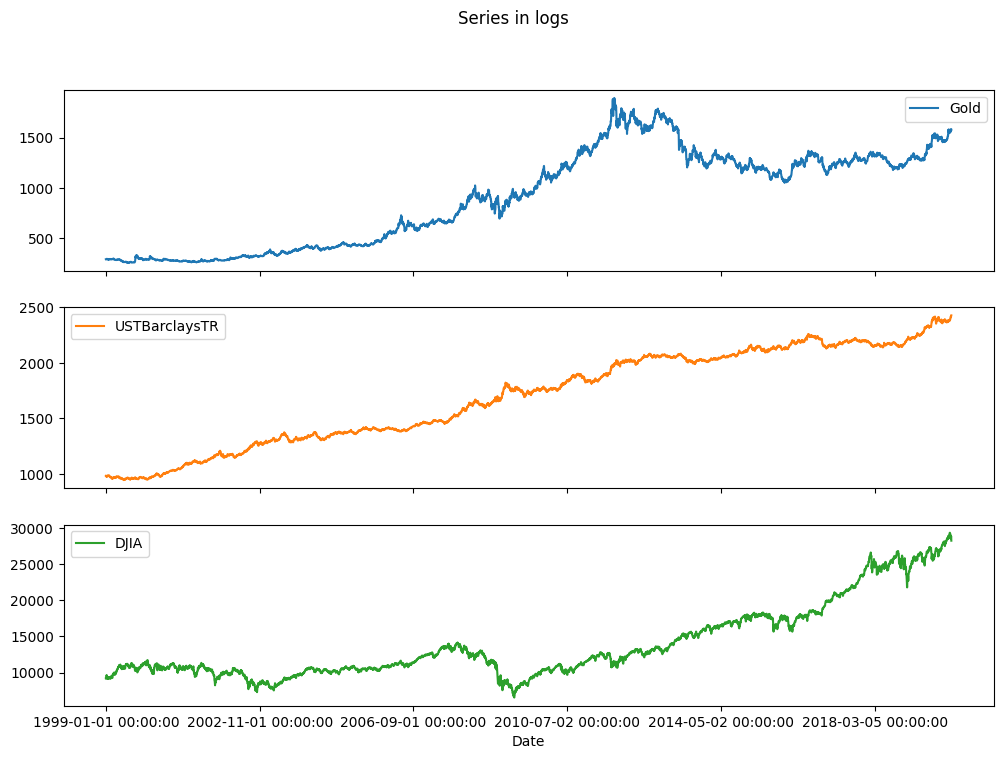

In [ ]:
data = pd.read_excel('/content/MSCIRUS_2020.xls', parse_dates=['Date'], date_format='%b-%Y', index_col='Date')
print(data.head())

df = data[['Gold', 'USTBarclaysTR', 'DJIA']]
# Визуализация исходных рядов
df.plot(subplots=True, figsize=(12, 8))
plt.suptitle("Series in logs")
plt.show()

In [ ]:
n = np.log(len(data['Gold']))
n

np.float64(8.612321536507814)

In [ ]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{name}: ADF = {result[0]:.3f}, p-value = {result[1]:.3f}')
    return result[1] > 0.05

print("--- Уровни ---")
for col in df.columns:
    adf_test(df[col], col)

# Берём первые разности
df_diff = np.log(df.diff().dropna())
df_diff.columns = [f'd1_{col}' for col in df.columns]

print("\n--- Первые разности ---")
for col in df_diff.columns:
    adf_test(df_diff[col], col)

--- Уровни ---
Gold: ADF = -0.666, p-value = 0.855
USTBarclaysTR: ADF = -0.318, p-value = 0.923
DJIA: ADF = 1.173, p-value = 0.996

--- Первые разности ---


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


LinAlgError: SVD did not converge

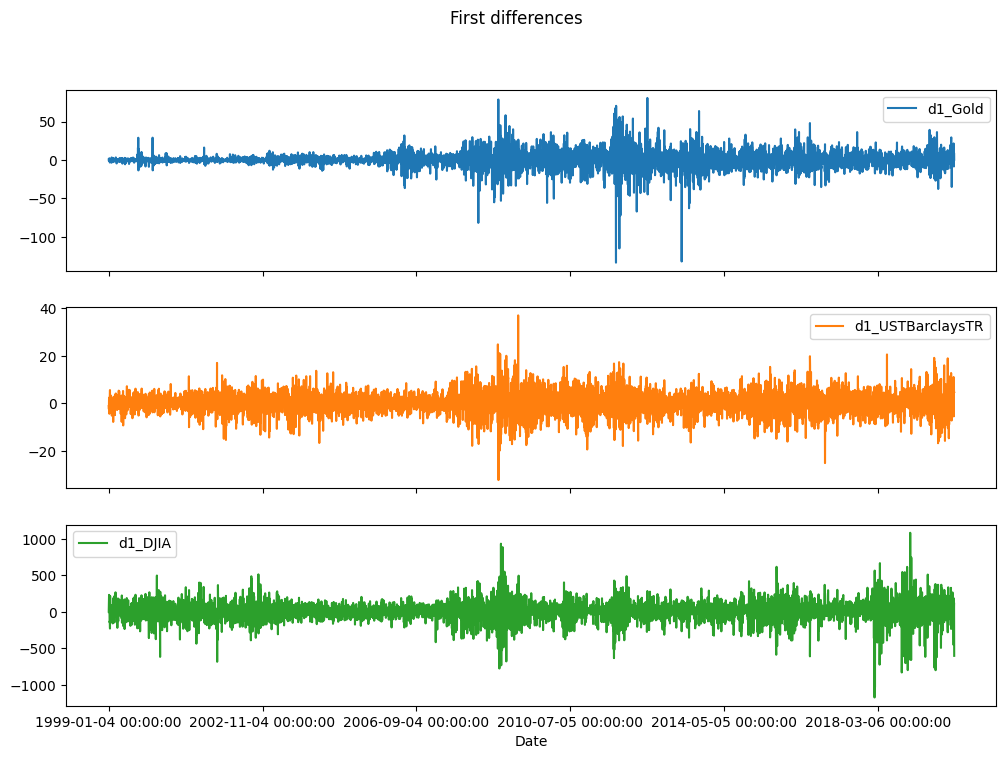

In [ ]:
df_diff.plot(subplots=True, figsize=(12, 8))
plt.suptitle("First differences")
plt.show()

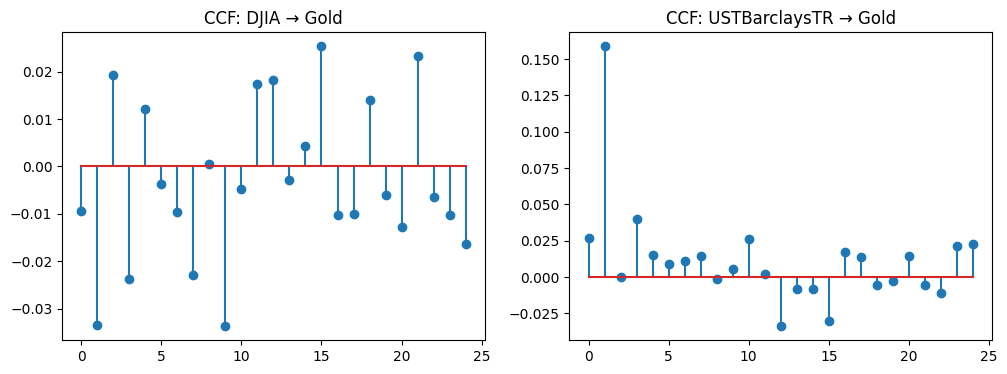


--- Granger DJIA → Gold ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

p-values: ['0.102', '0.066', '0.093', '0.167', '0.047', '0.011', '0.009', '0.015', '0.027', '0.022', '0.026', '0.031']

--- Granger USTBarclaysTR → Gold ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

p-values: ['0.207', '0.135', '0.200', '0.007', '0.008', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000']


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
y = df_diff['d1_Gold'].values
x_DJIA = df_diff['d1_DJIA'].values
x_ust = df_diff['d1_USTBarclaysTR'].values

# CCF
lags = 24
ccf_DJIA = ccf(y, x_DJIA)[:lags+1]
ccf_ust = ccf(y, x_ust)[:lags+1]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(range(lags+1), ccf_DJIA)
plt.title('CCF: DJIA → Gold')
plt.subplot(1,2,2)
plt.stem(range(lags+1), ccf_ust)
plt.title('CCF: USTBarclaysTR → Gold')
plt.show()


# Granger causality
maxlag = 12
print("\n--- Granger DJIA → Gold ---")
pvals_ipi = [grangercausalitytests(df_diff[['d1_DJIA','d1_Gold']], l, verbose=False)[l][0]['ssr_ftest'][1] for l in range(1,maxlag+1)]
print("p-values:", [f"{p:.3f}" for p in pvals_ipi])

print("\n--- Granger USTBarclaysTR → Gold ---")
pvals_cpi = [grangercausalitytests(df_diff[['d1_USTBarclaysTR','d1_Gold']], l, verbose=False)[l][0]['ssr_ftest'][1] for l in range(1,maxlag+1)]
print("p-values:", [f"{p:.3f}" for p in pvals_cpi])

In [ ]:
# Выбираем переменную с наименьшими p-value (например, IPI)
chosen_var = 'd1_USTBarclaysTR'
print(f"\n-> Выбрана переменная: {chosen_var}")

data_var2 = df_diff[['d1_Gold', chosen_var]].copy()
model2 = VAR(data_var2)
lag_order = model2.select_order(maxlags=32)
print(lag_order.summary())
p_opt = lag_order.aic
print(f"Оптимальный лаг по AIC: {p_opt}")

var2 = model2.fit(p_opt)
print(var2.summary())


-> Выбрана переменная: d1_USTBarclaysTR


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        7.862       7.864       2596.       7.863
1        7.835      7.842*       2528.      7.838*
2        7.835       7.847       2527.       7.839
3        7.833       7.850       2522.       7.839
4        7.831       7.853       2519.       7.839
5        7.832       7.858       2519.       7.841
6        7.830       7.862       2515.       7.841
7        7.829       7.866       2514.       7.842
8        7.829       7.871       2514.       7.844
9        7.830       7.876       2514.       7.846
10       7.830       7.881       2514.       7.847
11      7.829*       7.885      2513.*       7.849
12       7.830       7.890       2514.       7.851
13       7.830       7.895       2515.       7.853
14       7.830       7.900       2516.       7.855
15       7.829       7.904       2514.       7.856
16       7.830       7.909     

In [ ]:
whiteness = var2.test_whiteness(nlags=12, adjusted=True)
print(whiteness.summary())

Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         7.311          9.488   0.120  4
----------------------------------------


Хоскинг: стат. = 278286966207.474, p-значение = 0.000
Ли-МакЛид: стат. = 278286966207.474, p-значение = 0.000


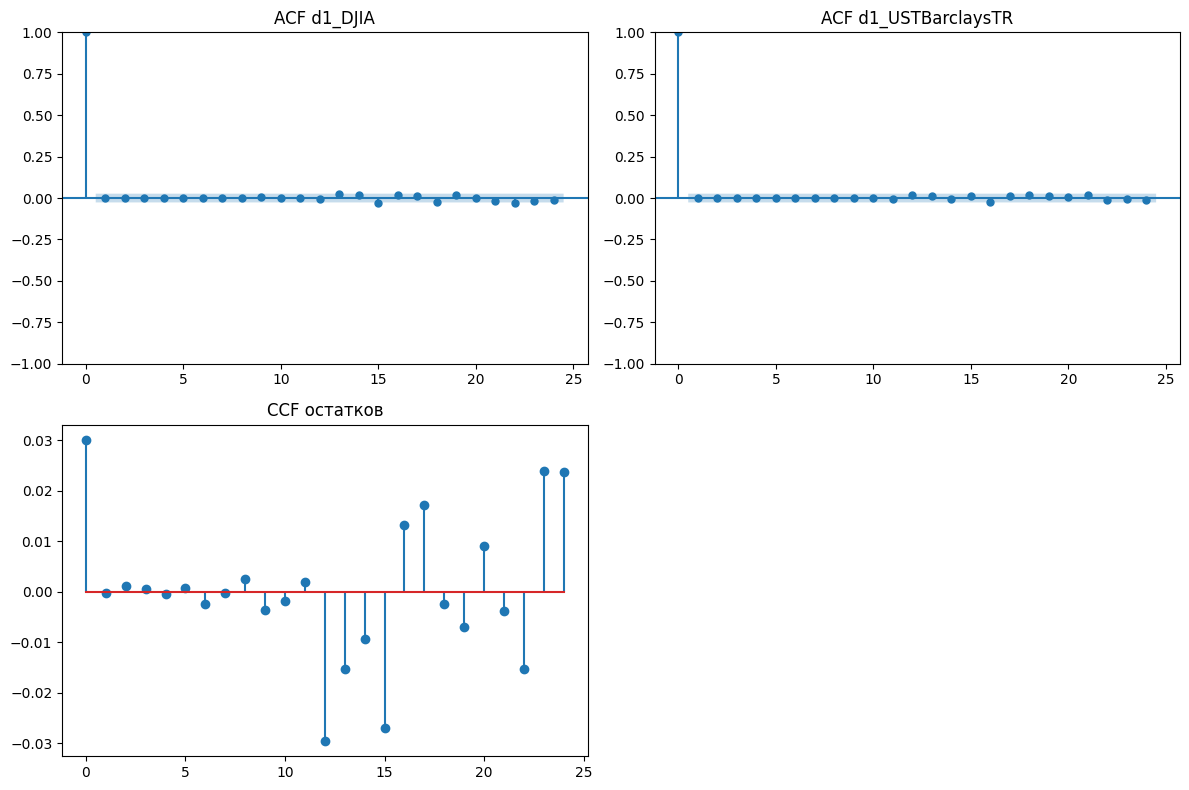

In [ ]:
import math

resid2 = var2.resid
lags_test = math.floor(np.log(len(resid2)))

# Используем наши функции (R или Python)
stat_h, p_h = hosking_test(resid2, lags_test)
print(f"Хоскинг: стат. = {stat_h:.3f}, p-значение = {p_h:.3f}")

stat_lm, p_lm = limcleod_test(resid2, lags_test)
print(f"Ли-МакЛид: стат. = {stat_lm:.3f}, p-значение = {p_lm:.3f}")

# Дополнительно визуализация ACF и CCF
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(2,2, figsize=(12,8))
plot_acf(resid2['d1_Gold'], ax=axes[0,0], lags=24, title='ACF d1_DJIA')
plot_acf(resid2[chosen_var], ax=axes[0,1], lags=24, title=f'ACF {chosen_var}')
ccf_res = ccf(resid2['d1_Gold'], resid2[chosen_var])[:25]
axes[1,0].stem(range(25), ccf_res)
axes[1,0].set_title('CCF остатков')
axes[1,1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
data_var3 = df_diff[['d1_Gold', 'd1_DJIA', 'd1_USTBarclaysTR']].copy()
model3 = VAR(data_var3)
lag_order3 = model3.select_order(maxlags=12)
p_opt3 = lag_order3.aic
var3 = model3.fit(p_opt3)
print(f"VAR(3) с лагом {p_opt3}")

# F-тест для включения CPI
# Исправленная ячейка для F-теста (с преобразованием в float)
common_sample = data_var3.iloc[p_opt3:]
var2_on_common = VAR(common_sample[['d1_Gold','d1_USTBarclaysTR']]).fit(p_opt3)

# Используем .to_numpy() для получения чистого массива
rss_r = np.sum(var2_on_common.resid.to_numpy() ** 2)
rss_u = np.sum(var3.resid.to_numpy() ** 2)

T = len(common_sample)
k_r = 2 * p_opt3 + 1
k_u = 3 * p_opt3 + 1
df1 = k_u - k_r
df2 = T - k_u
F_stat = ((rss_r - rss_u) / df1) / (rss_u / df2)
p_F = 1 - stats.f.cdf(F_stat, df1, df2)

print(f"F-тест: F = {F_stat:.3f}, p-значение = {p_F:.3f}")

if p_F < 0.05:
    best_var = var3
    print("→ DJIA значима, выбираем VAR(3)")
else:
    best_var = var2
    print("→ DJIA незначима, оставляем VAR(2)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


VAR(3) с лагом 6
F-тест: F = -905.604, p-значение = 1.000
→ DJIA незначима, оставляем VAR(2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


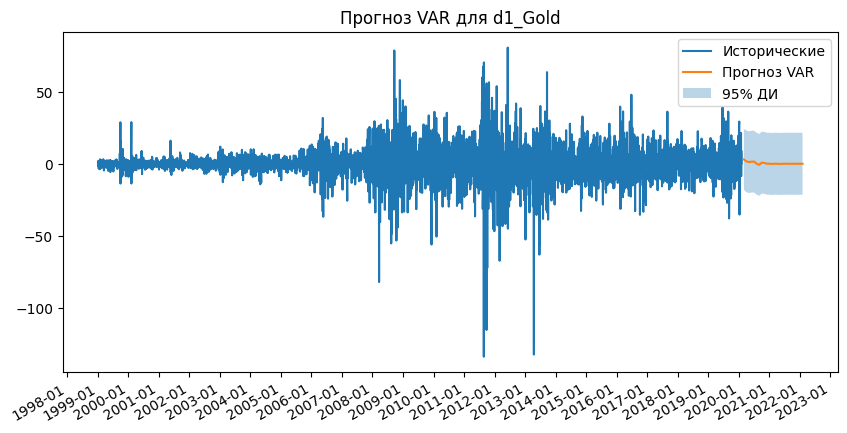

In [ ]:
import matplotlib.dates as mdates

# Прогноз для первых разностей
forecast_steps = 24

# Последние p наблюдений из обучающих данных
last_obs = best_var.endog[-best_var.k_ar:]  # массив формы (p, n)

# Интервальный прогноз
fc, lower, upper = best_var.forecast_interval(y=last_obs, steps=forecast_steps, alpha=0.05)

# Даты для прогноза (начинаем с месяца, следующего за последним в данных)
last_date = df_diff.index[-1]
fc_dates = pd.date_range(start=last_date, periods=forecast_steps+1, freq='MS')[1:]

# Convert all dates to numeric (ordinal) values for plotting
hist_dates_num = mdates.date2num(df_diff.index)   # Directly pass the index
fc_dates_num = mdates.date2num(fc_dates)          # fc_dates is already DatetimeIndex

# Визуализация
plt.figure(figsize=(10,5))
plt.plot(hist_dates_num, df_diff['d1_Gold'], label='Исторические')
plt.plot(fc_dates_num, fc[:, 0], label='Прогноз VAR')
plt.fill_between(fc_dates_num, lower[:, 0], upper[:, 0], alpha=0.3, label='95% ДИ')

# Format x-axis as dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()  # автоматический поворот меток

plt.title('Прогноз VAR для d1_Gold')
plt.legend()
plt.show()

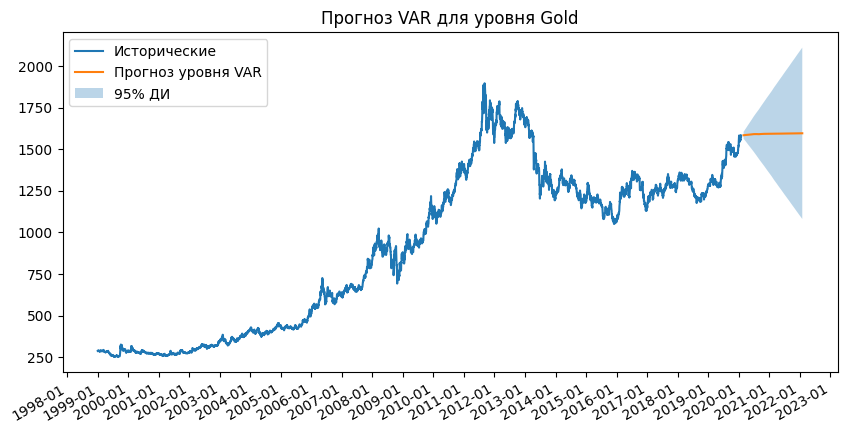

In [ ]:
import matplotlib.dates as mdates

# Прогноз для уровня Gold
last_level = df['Gold'].iloc[-1]

# Накопление прогнозов разностей
level_fc = np.cumsum(np.concatenate(([last_level], fc[:, 0])))[1:]
level_low = np.cumsum(np.concatenate(([last_level], lower[:, 0])))[1:]
level_up = np.cumsum(np.concatenate(([last_level], upper[:, 0])))[1:]

# Преобразование дат в числовой формат для корректной работы с matplotlib
hist_dates_num = mdates.date2num(df.index)
fc_dates_num = mdates.date2num(fc_dates)

# Визуализация
plt.figure(figsize=(10,5))
plt.plot(hist_dates_num, df['Gold'], label='Исторические')
plt.plot(fc_dates_num, level_fc, label='Прогноз уровня VAR')
plt.fill_between(fc_dates_num, level_low, level_up, alpha=0.3, label='95% ДИ')

# Форматирование оси X как дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

plt.title('Прогноз VAR для уровня Gold')
plt.legend()
plt.show()

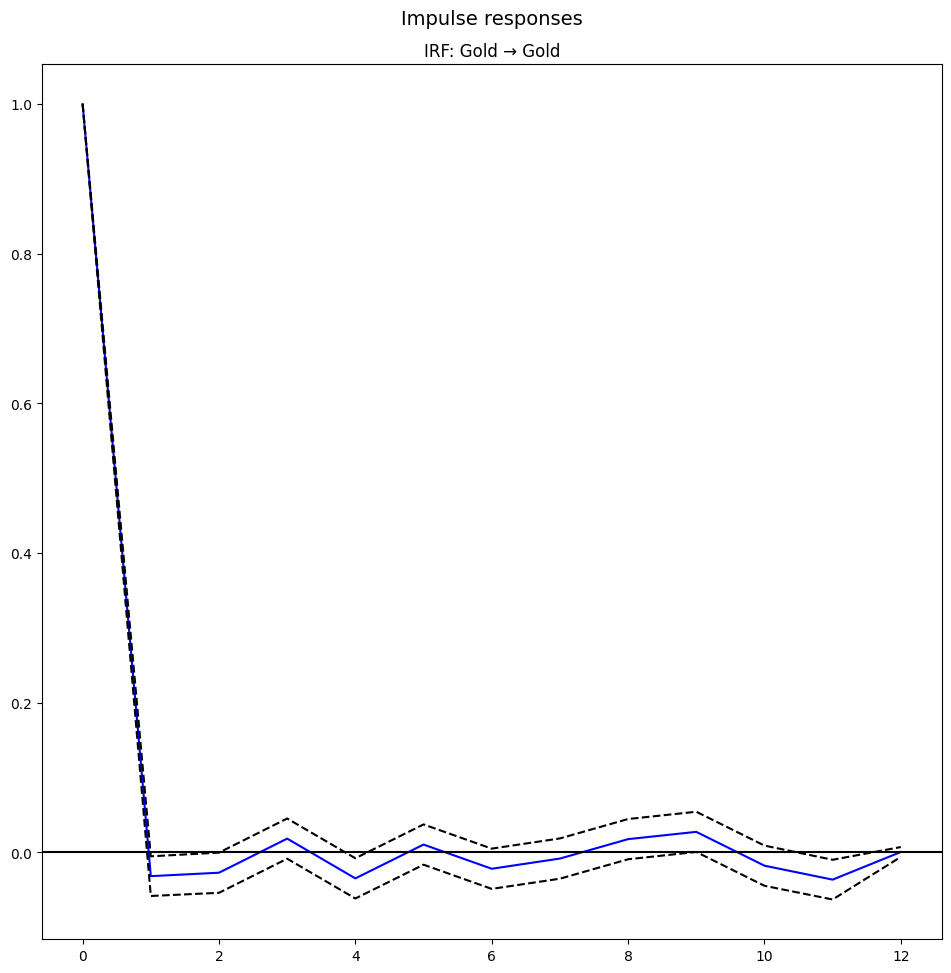

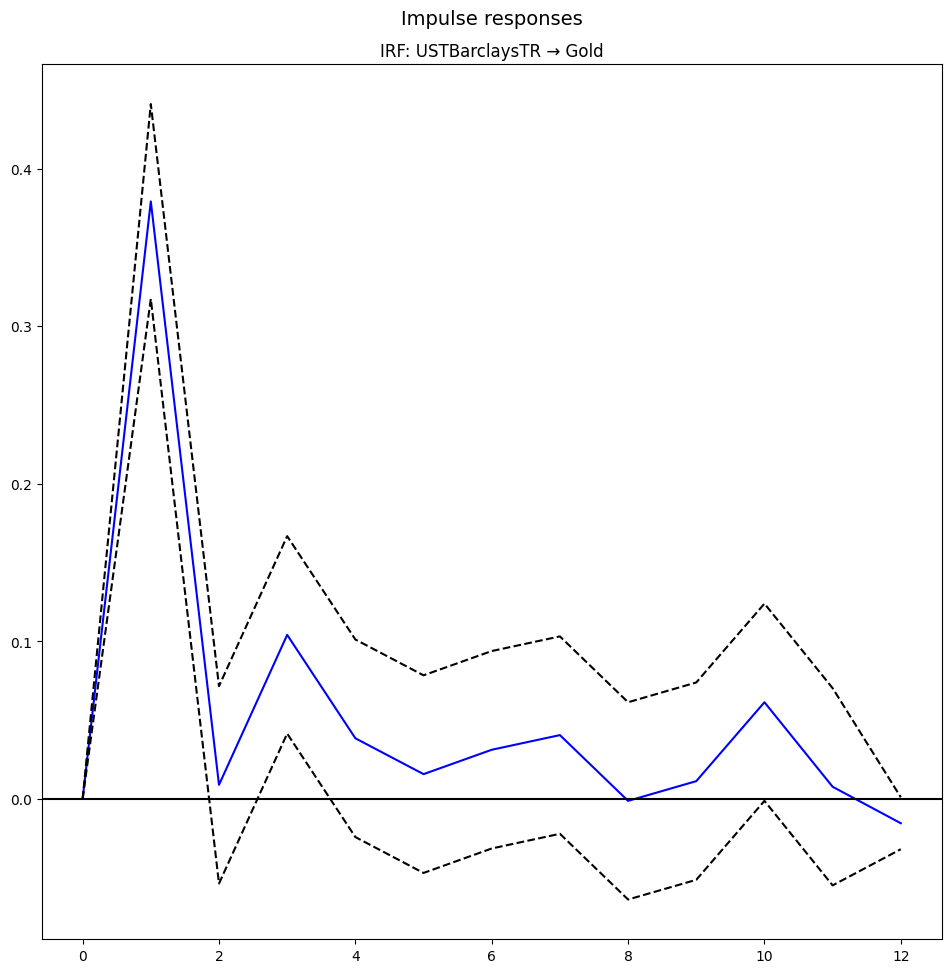

In [ ]:
# Стандартные IRF
irf_std = best_var.irf(periods=12)
irf_std.plot(orth=False, impulse='d1_Gold', response='d1_Gold')
plt.title('IRF: Gold → Gold')
plt.show()
if best_var.neqs > 1:
    irf_std.plot(orth=False, impulse='d1_USTBarclaysTR', response='d1_Gold')
    plt.title('IRF: USTBarclaysTR → Gold')
    plt.show()
if best_var.neqs > 2:
    irf_std.plot(orth=False, impulse='d1_DJIA', response='d1_DJIA')
    plt.title('IRF: DJIA → Gold')
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


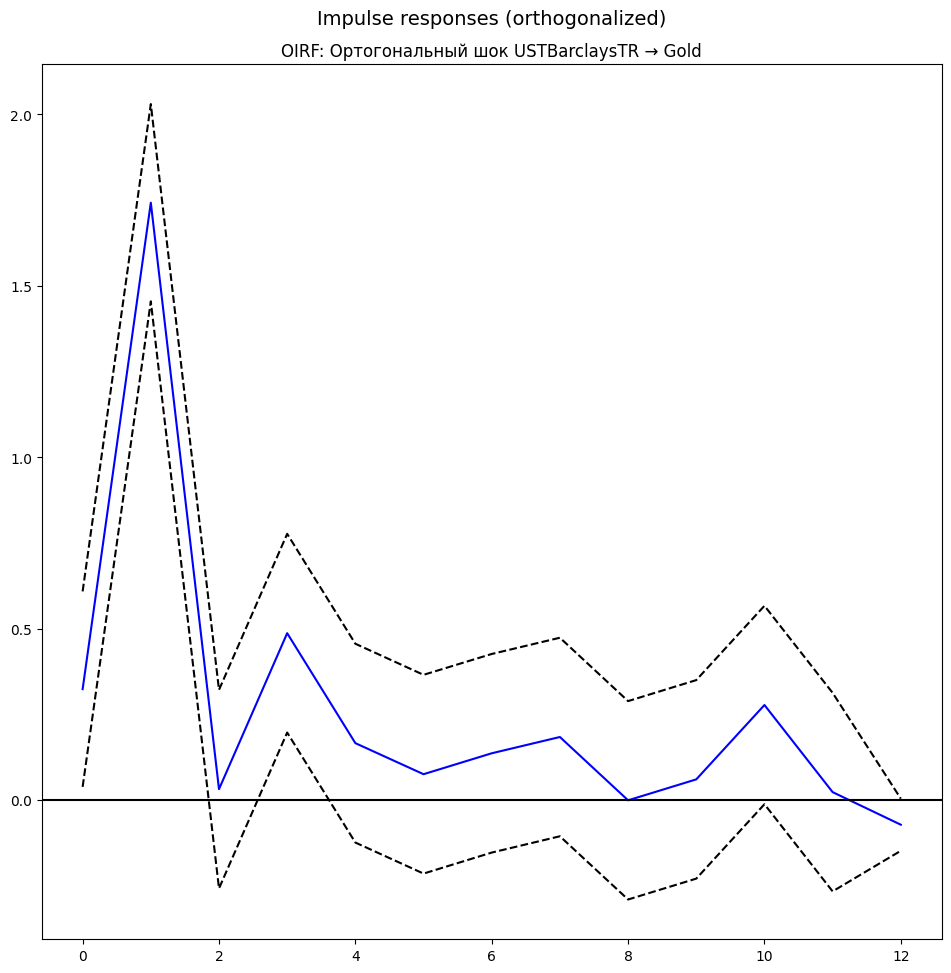

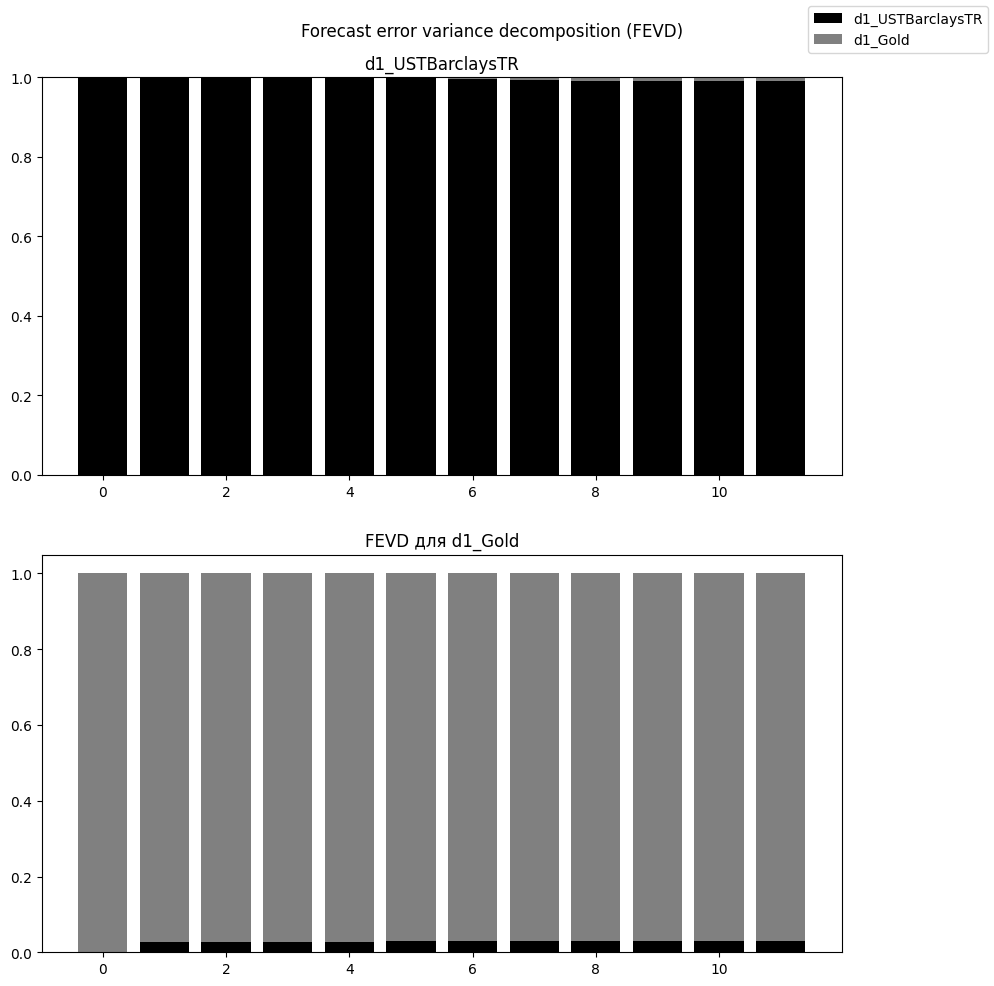

FEVD for d1_USTBarclaysTR
      d1_USTBarclaysTR   d1_Gold
0             1.000000  0.000000
1             0.999826  0.000174
2             0.999241  0.000759
3             0.999217  0.000783
4             0.997242  0.002758
5             0.997243  0.002757
6             0.994716  0.005284
7             0.992751  0.007249
8             0.991577  0.008423
9             0.991569  0.008431
10            0.991561  0.008439
11            0.991184  0.008816

FEVD for d1_Gold
      d1_USTBarclaysTR   d1_Gold
0             0.000905  0.999095
1             0.026346  0.973654
2             0.026336  0.973664
3             0.028260  0.971740
4             0.028452  0.971548
5             0.028496  0.971504
6             0.028635  0.971365
7             0.028909  0.971091
8             0.028900  0.971100
9             0.028909  0.971091
10            0.029524  0.970476
11            0.029491  0.970509


None


In [ ]:
data_ordered = data_var2[['d1_USTBarclaysTR', 'd1_Gold']]
order = ['d1_USTBarclaysTR', 'd1_Gold']

var_ordered = VAR(data_ordered).fit(best_var.k_ar)
irf_orth = var_ordered.irf(periods=12)

# Графики OIRF
if best_var.neqs >= 2:
    irf_orth.plot(orth=True, impulse='d1_USTBarclaysTR', response='d1_Gold')
    plt.title('OIRF: Ортогональный шок USTBarclaysTR → Gold')
    plt.show()

# FEVD
fevd = var_ordered.fevd(periods=12)
fevd.plot()
plt.title('FEVD для d1_Gold')
plt.show()
print(fevd.summary())